In [1]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

from src import data, beta, portfolios, evaluate

In [2]:
frames = data.build_dataset(start="1990-01-01", end="2024-12-31")
daily      = frames["daily"]
monthly    = frames["monthly"]
ff_daily   = frames["ff_daily"]
ff_monthly = frames["ff_monthly"]

market = (ff_daily.set_index("date")["mktrf"] + ff_daily.set_index("date")["rf"])

In [ ]:
beta_long = beta.betas_long(daily, market)
beta_long["date"].min(), beta_long["date"].max(), len(beta_long)

rf = ff_monthly[["date", "rf"]]
bab = portfolios.bab_returns(beta_long, monthly, rf)

results = evaluate.evaluate(bab, ff_monthly)

In [5]:
# Accuracy Test
bab_aqr = pd.read_excel("BAB_AQR.xlsx", skiprows=18)
bab_aqr["month"] = pd.to_datetime(bab_aqr["DATE"]).dt.to_period("M")

mine = results["merged"][["month", "bab"]].rename(columns={"bab": "bab_mine"})
aqr = bab_aqr[["month", "USA"]].rename(columns={"USA": "bab_aqr"})
comp = mine.merge(aqr, on="month", how="inner").sort_values("month").reset_index(drop=True)

y = comp["bab_mine"]
X = sm.add_constant(comp["bab_aqr"])

res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

alpha_m = res.params["const"]
beta    = res.params["bab_aqr"]

print(f"Overlapping months: {len(comp)}")
print(f"Intercept (alpha):  {alpha_m:.5f}/mo   ({alpha_m*12:.4f}/yr)   t = {res.tvalues['const']:.2f}")
print(f"Slope (beta):       {beta:.3f}                     t = {res.tvalues['bab_aqr']:.2f}")
print(f"R-squared:          {res.rsquared:.3f}")
print(f"Correlation:        {comp['bab_mine'].corr(comp['bab_aqr']):.3f}")

Overlapping months: 384
Intercept (alpha):  0.00104/mo   (0.0124/yr)   t = 1.88
Slope (beta):       0.986                     t = 48.36
R-squared:          0.930
Correlation:        0.964


In [6]:
# Proposition 1: beta-sorted deciles show declining alpha & Sharpe

# --- build the ten decile return series (vectorized) ---
signal = portfolios.monthly_beta_signal(beta_long)
rets   = portfolios.prepare_monthly_returns(monthly)

panel = signal.merge(
    rets, left_on=["permno", "signal_month"],
    right_on=["permno", "month"], how="inner",
).dropna(subset=["beta", "ret"])

panel["decile"] = (
    panel.groupby("signal_month")["beta"]
    .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))
)

decile_rets = (
    panel.groupby(["signal_month", "decile"])["ret"]
    .mean()
    .reset_index()
    .rename(columns={"signal_month": "month"})
)

# --- alpha & Sharpe per decile (20 regressions: 10 deciles x 2 models) ---
ff = ff_monthly.copy()
ff["month"] = ff["date"].dt.to_period("M")

table3_rows = []
for dec, grp in decile_rets.groupby("decile"):
    m = grp.merge(ff, on="month", how="inner").sort_values("month")
    y = m["ret"] - m["rf"]

    rc  = sm.OLS(y, sm.add_constant(m[["mktrf"]])
                 ).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    rf4 = sm.OLS(y, sm.add_constant(m[["mktrf", "smb", "hml", "umd"]])
                 ).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

    table3_rows.append({
        "decile":         dec + 1,
        "excess_ret_ann": y.mean() * 12,
        "capm_alpha_ann": rc.params["const"] * 12,
        "capm_t":         rc.tvalues["const"],
        "ff4_alpha_ann":  rf4.params["const"] * 12,
        "ff4_t":          rf4.tvalues["const"],
        "sharpe_ann":     (y.mean() / y.std()) * np.sqrt(12),
    })

table3 = pd.DataFrame(table3_rows).set_index("decile")
print(table3)

        excess_ret_ann  capm_alpha_ann    capm_t  ff4_alpha_ann     ff4_t  \
decile                                                                      
1             0.119422        0.070762  2.919657       0.070651  3.794092   
2             0.116440        0.054338  2.257485       0.055564  3.184026   
3             0.124735        0.053658  2.488550       0.054265  4.079924   
4             0.120858        0.040860  1.939656       0.043093  3.339363   
5             0.135521        0.045421  2.162065       0.050034  4.273843   
6             0.118940        0.020613  0.957833       0.029163  2.557940   
7             0.120680        0.013769  0.611611       0.026697  2.149400   
8             0.113054       -0.007980 -0.327923       0.016995  1.153265   
9             0.112705       -0.026277 -0.940815       0.012800  0.718184   
10            0.120912       -0.060113 -1.457930       0.002740  0.090621   

        sharpe_ann  
decile              
1         0.914086  
2         0.

In [7]:
# Prop 2
print("Sharpe (ann):   ", round(results["summary"]["sharpe_ann"], 2))
print("CAPM alpha:     ", round(results["capm"]["alpha_ann"], 4),
      " t =", round(results["capm"]["alpha_t"], 2))
print("FF3+UMD alpha:  ", round(results["ff4"]["alpha_ann"], 4),
      " t =", round(results["ff4"]["alpha_t"], 2))
print("FF loadings:    ", {k: round(v, 3) for k, v in results["ff4"]["loadings"].items()})

Sharpe (ann):    0.74
CAPM alpha:      0.1193  t = 3.56
FF3+UMD alpha:   0.0863  t = 3.11
FF loadings:     {'mktrf': -0.091, 'smb': -0.087, 'hml': 0.42, 'umd': 0.282}


In [9]:
#Prop 3
nfci_raw = web.DataReader(["NFCI", "NFCILEVERAGE"], "fred", "1990-01-01", "2024-12-31")
nfci_m = nfci_raw.resample("ME").last()
nfci_m["month"] = nfci_m.index.to_period("M")

fund = nfci_m[["month", "NFCI", "NFCILEVERAGE"]].reset_index(drop=True)
fund["nfci_lag"]   = fund["NFCI"].shift(1)      # level known at start of month t (end of t-1)
fund["nfci_chg"]   = fund["NFCI"].diff()        # contemporaneous change over month t

# --- join to BAB and run FP's Table 9 regression ---
reg = bab[["month", "bab"]].merge(fund, on="month", how="inner").dropna(
    subset=["bab", "nfci_lag", "nfci_chg"]
)

y = reg["bab"]
X = sm.add_constant(reg[["nfci_lag", "nfci_chg"]])
res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})

print(f"Sample: {reg['month'].min()} to {reg['month'].max()}  (n={len(reg)})")
print(f"Lagged NFCI level:   {res.params['nfci_lag']:+.5f}   t = {res.tvalues['nfci_lag']:+.2f}")
print(f"Change in NFCI:      {res.params['nfci_chg']:+.5f}   t = {res.tvalues['nfci_chg']:+.2f}")
print(f"R-squared:           {res.rsquared:.3f}")

# --- COVID as the showcase episode: BAB return vs NFCI spike, early 2020 ---
covid = reg[(reg["month"] >= pd.Period("2019-10", "M")) &
            (reg["month"] <= pd.Period("2020-06", "M"))]
print("\nCOVID window (BAB return vs NFCI level):")
print(covid[["month", "bab", "NFCI"]].to_string(index=False))

Sample: 1993-01 to 2024-12  (n=384)
Lagged NFCI level:   -0.01876   t = -4.03
Change in NFCI:      -0.05344   t = -3.72
R-squared:           0.078

COVID window (BAB return vs NFCI level):
  month       bab   NFCI
2019-10 -0.003562 -0.554
2019-11 -0.020088 -0.574
2019-12 -0.016590 -0.559
2020-01  0.048574 -0.626
2020-02 -0.024414 -0.293
2020-03 -0.060681  0.275
2020-04 -0.046763  0.162
2020-05  0.056488 -0.270
2020-06  0.073714 -0.386


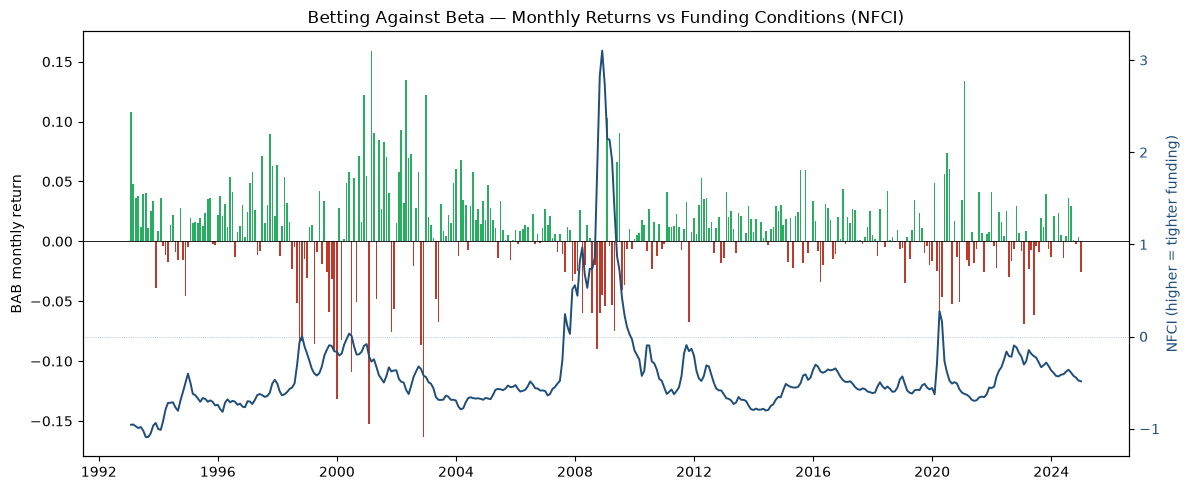

In [10]:
m = results["merged"].copy()
m["date"] = m["month"].dt.to_timestamp("M")

m = m.merge(fund[["month", "NFCI"]], on="month", how="left")

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#c0392b" if r < 0 else "#27ae60" for r in m["bab"]]
ax.bar(m["date"], m["bab"], width=20, color=colors, zorder=1)
ax.axhline(0, color="black", linewidth=0.6, zorder=2)
ax.set_ylabel("BAB monthly return")
ax.set_xlabel("")

ax2 = ax.twinx()
ax2.plot(m["date"], m["NFCI"], color="#1f4e79", linewidth=1.4, zorder=3, label="NFCI")
ax2.axhline(0, color="#1f4e79", linewidth=0.5, linestyle=":", alpha=0.5)
ax2.set_ylabel("NFCI (higher = tighter funding)", color="#1f4e79")
ax2.tick_params(axis="y", labelcolor="#1f4e79")

ax.set_title("Betting Against Beta — Monthly Returns vs Funding Conditions (NFCI)")
plt.tight_layout()
plt.show()